In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow import keras
from tensorflow.keras import layers

In [79]:
csv_path = "data/sp500_5yr_with_sectors_weights.csv"

df = pd.read_csv(csv_path)

if "Weight" in df.columns:
    df = df.drop(columns=["Weight"])

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Symbol", "Date"]).reset_index(drop=True)

# df.head()

In [80]:
# time periods for splitting

TRAIN_START = pd.Timestamp("2021-03-22")
TRAIN_END   = pd.Timestamp("2024-03-20")

VAL_START   = pd.Timestamp("2024-03-21")
VAL_END     = pd.Timestamp("2025-03-20")

UNSEEN_START = pd.Timestamp("2025-03-21")
UNSEEN_END   = pd.Timestamp("2026-03-20")

In [81]:
# keep only stocks that have data in all 3 periods to avoid unseen stock issues

train_symbols = set(df.loc[(df["Date"] >= TRAIN_START) & (df["Date"] <= TRAIN_END), "Symbol"].unique())
val_symbols = set(df.loc[(df["Date"] >= VAL_START) & (df["Date"] <= VAL_END), "Symbol"].unique())
unseen_symbols = set(df.loc[(df["Date"] >= UNSEEN_START) & (df["Date"] <= UNSEEN_END), "Symbol"].unique())

common_symbols = sorted(train_symbols & val_symbols & unseen_symbols)

df = df[df["Symbol"].isin(common_symbols)].copy()
df = df.sort_values(["Symbol", "Date"]).reset_index(drop=True)

print("Common stocks:", df["Symbol"].nunique())

Common stocks: 499


In [82]:
# split into train/val/unseen

train_df = df[(df["Date"] >= TRAIN_START) & (df["Date"] <= TRAIN_END)].copy()
val_df = df[(df["Date"] >= VAL_START) & (df["Date"] <= VAL_END)].copy()
unseen_df = df[(df["Date"] >= UNSEEN_START) & (df["Date"] <= UNSEEN_END)].copy()

print("Train stocks:", train_df["Symbol"].nunique())
print("Val stocks:", val_df["Symbol"].nunique())
print("Unseen stocks:", unseen_df["Symbol"].nunique())

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Unseen shape:", unseen_df.shape)

Train stocks: 499
Val stocks: 499
Unseen stocks: 499
Train shape: (374800, 9)
Val shape: (124750, 9)
Unseen shape: (125248, 9)


In [83]:
# export and remove unseen

unseen_df.to_csv("unseen_holdout_raw.csv", index=False)

df = pd.concat([train_df, val_df], axis=0).sort_values(["Symbol", "Date"]).reset_index(drop=True)

print("Model dataframe shape:", df.shape)
print("Train + Val Date range:", df["Date"].min(), "to", df["Date"].max())

Model dataframe shape: (499550, 9)
Train + Val Date range: 2021-03-22 00:00:00 to 2025-03-20 00:00:00


In [84]:
# feature engineering function

import numpy as np

def engineer_features(panel_df):
    panel_df = panel_df.copy()
    g = panel_df.groupby("Symbol")

    panel_df["log_return_1d"] = g["Close"].transform(lambda x: np.log(x / x.shift(1)))
    panel_df["daily_volatility"] = panel_df["log_return_1d"].abs()
    panel_df["target"] = g["log_return_1d"].transform(lambda x: x.abs().shift(-1))

    for lag in [1, 2, 5, 21]:
        panel_df[f"daily_volatility_lag_{lag}d"] = g["daily_volatility"].shift(lag)

    for lag in [1, 5]:
        panel_df[f"close_lag_{lag}d"] = g["Close"].shift(lag)

    panel_df["volume_lag_1d"] = g["Volume"].shift(1)
    panel_df["volume_lag_5d"] = g["Volume"].shift(5)
    panel_df["volume_pct_change_1d"] = g["Volume"].pct_change()

    return panel_df


In [85]:
# apply feature engineering to dev set

df = engineer_features(df)

feature_cols = [
    "close_lag_1d",
    "close_lag_5d",
    "daily_volatility_lag_1d",
    "daily_volatility_lag_2d",
    "daily_volatility_lag_5d",
    "daily_volatility_lag_21d",
    "volume_lag_1d",
    "volume_lag_5d",
    "volume_pct_change_1d",
]

target_col = "target"

df = df.dropna(subset=feature_cols + [target_col]).copy()

finite_mask = np.isfinite(df[feature_cols + [target_col]]).all(axis=1)
dropped_nonfinite = (~finite_mask).sum()
if dropped_nonfinite:
    print(f"Dropping {dropped_nonfinite} non-finite rows from dev set (inf/-inf).")

df = df.loc[finite_mask].copy()

print(df.shape)
df.head()


Dropping 179 non-finite rows from dev set (inf/-inf).
(487691, 21)


,Date,Open,High,Low,Close,Volume,Symbol,Security,Sector,log_return_1d,...,target,daily_volatility_lag_1d,daily_volatility_lag_2d,daily_volatility_lag_5d,daily_volatility_lag_21d,close_lag_1d,close_lag_5d,volume_lag_1d,volume_lag_5d,volume_pct_change_1d
22,2021-04-22,129.730502,131.114637,129.536920,130.214462,1732700,A,Agilent Technologies,Health Care,0.005217,...,0.015855,0.010289,0.007821,0.009877,0.013274,129.536942,129.004578,1173900.0,2121300.0,0.476020
23,2021-04-23,130.253217,132.721405,130.185455,132.295517,1495200,A,Agilent Technologies,Health Care,0.015855,...,0.004817,0.005217,0.010289,0.009707,0.009390,130.214462,130.262878,1732700.0,4495400.0,-0.137069
24,2021-04-26,132.808491,133.408598,132.295479,132.934311,1287400,A,Agilent Technologies,Health Care,0.004817,...,0.006282,0.015855,0.005217,0.008057,0.008734,132.295517,129.217545,1495200.0,1071600.0,-0.138978
25,2021-04-27,132.537460,133.031109,131.859918,132.101898,1752900,A,Agilent Technologies,Health Care,-0.006282,...,0.012386,0.004817,0.015855,0.007821,0.030219,132.934311,128.210922,1287400.0,1261200.0,0.361581
26,2021-04-28,131.637318,132.130952,130.388705,130.475815,1603900,A,Agilent Technologies,Health Care,-0.012386,...,0.004834,0.006282,0.004817,0.010289,0.001752,132.101898,129.536942,1752900.0,1173900.0,-0.085002


In [86]:
# just look at features and target for now

df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Symbol', 'Security',
       'Sector', 'log_return_1d', 'daily_volatility', 'target',
       'daily_volatility_lag_1d', 'daily_volatility_lag_2d',
       'daily_volatility_lag_5d', 'daily_volatility_lag_21d', 'close_lag_1d',
       'close_lag_5d', 'volume_lag_1d', 'volume_lag_5d',
       'volume_pct_change_1d'],
      dtype='object')

In [87]:
# create train/val sets for modeling

train_feat = df[(df["Date"] >= TRAIN_START) & (df["Date"] <= TRAIN_END)].copy()
val_feat = df[(df["Date"] >= VAL_START) & (df["Date"] <= VAL_END)].copy()

print(train_feat.shape, val_feat.shape)
print(train_feat["Symbol"].nunique(), val_feat["Symbol"].nunique())

(363485, 21) (124206, 21)
499 499


In [88]:
LOOKBACK = 21

def make_sequences(panel_df, feature_cols, target_col, lookback=21):
    X_list = []
    y_list = []
    meta_list = []

    for symbol, g in panel_df.groupby("Symbol"):
        g = g.sort_values("Date").reset_index(drop=True)

        X_values = g[feature_cols].values
        y_values = g[target_col].values
        dates = g["Date"].values

        for t in range(lookback - 1, len(g)):
            X_window = X_values[t - lookback + 1 : t + 1]
            y_target = y_values[t]

            X_list.append(X_window)
            y_list.append(y_target)
            meta_list.append({
                "Symbol": symbol,
                "Date": dates[t]
            })

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.float32)
    meta = pd.DataFrame(meta_list)

    return X, y, meta

In [89]:
# build sequences for train/val

X_train, y_train, meta_train = make_sequences(
    train_feat,
    feature_cols=feature_cols,
    target_col=target_col,
    lookback=LOOKBACK
)

X_val, y_val, meta_val = make_sequences(
    val_feat,
    feature_cols=feature_cols,
    target_col=target_col,
    lookback=LOOKBACK
)

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)

Train: (353505, 21, 9) (353505,)
Val: (114226, 21, 9) (114226,)


In [90]:
# scale features and target using train stats

n_features = X_train.shape[2]

train_2d = X_train.reshape(-1, n_features)
feature_means = train_2d.mean(axis=0)
feature_stds = train_2d.std(axis=0) + 1e-8

X_train_scaled = (X_train - feature_means) / feature_stds
X_val_scaled = (X_val - feature_means) / feature_stds

y_mean = y_train.mean()
y_std = y_train.std() + 1e-8

y_train_scaled = (y_train - y_mean) / y_std
y_val_scaled = (y_val - y_mean) / y_std

In [91]:
# build model

keras.utils.set_random_seed(42)

model = keras.Sequential([
    layers.Input(shape=(LOOKBACK, len(feature_cols))),
    layers.LSTM(32),
    layers.Dense(16, activation="relu"),
    layers.Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 32)             │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,921 (23.13 KB)

 Trainable params: 5,921 (23.13 KB)

 Non-trainable params: 0 (0.00 B)

In [92]:
# train

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )
]

history = model.fit(
    X_train_scaled,
    y_train_scaled,
    validation_data=(X_val_scaled, y_val_scaled),
    epochs=100,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
5524/5524 ━━━━━━━━━━━━━━━━━━━━ 67s 11ms/step - loss: 0.8614 - mae: 0.6127 - val_loss: 0.9024 - val_mae: 0.5733
Epoch 2/100
5524/5524 ━━━━━━━━━━━━━━━━━━━━ 61s 11ms/step - loss: 0.8514 - mae: 0.6099 - val_loss: 0.9017 - val_mae: 0.5734
Epoch 3/100
5524/5524 ━━━━━━━━━━━━━━━━━━━━ 59s 11ms/step - loss: 0.8479 - mae: 0.6089 - val_loss: 0.9022 - val_mae: 0.5728
Epoch 4/100
5524/5524 ━━━━━━━━━━━━━━━━━━━━ 78s 14ms/step - loss: 0.8447 - mae: 0.6082 - val_loss: 0.9012 - val_mae: 0.5740
Epoch 5/100
5524/5524 ━━━━━━━━━━━━━━━━━━━━ 83s 15ms/step - loss: 0.8415 - mae: 0.6076 - val_loss: 0.9019 - val_mae: 0.5749
Epoch 6/100
5524/5524 ━━━━━━━━━━━━━━━━━━━━ 84s 15ms/step - loss: 0.8384 - mae: 0.6070 - val_loss: 0.9025 - val_mae: 0.5748
Epoch 7/100
5524/5524 ━━━━━━━━━━━━━━━━━━━━ 77s 14ms/step - loss: 0.8349 - mae: 0.6064 - val_loss: 0.9036 - val_mae: 0.5746
Epoch 8/100
5524/5524 ━━━━━━━━━━━━━━━━━━━━ 79s 14ms/step - loss: 0.8314 - mae: 0.6058 - val_loss: 0.9040 - val_mae: 0.5748
Epoch 9/100
5524

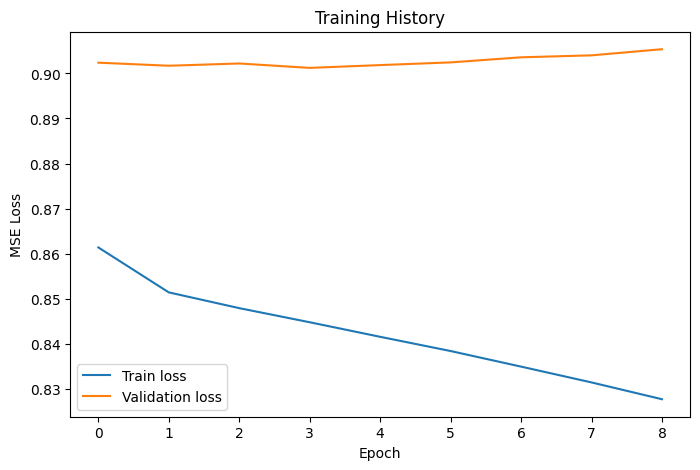

In [93]:
# plot training curve

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.title("Training History")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

In [94]:
# load unseen

unseen_df = pd.read_csv("data/sp500_unseen.csv")

unseen_df["Date"] = pd.to_datetime(unseen_df["Date"])
unseen_df = unseen_df.sort_values(["Symbol", "Date"]).reset_index(drop=True)

print(unseen_df["Date"].min(), unseen_df["Date"].max())
print(unseen_df.shape)
print("Stocks:", unseen_df["Symbol"].nunique())

2025-03-21 00:00:00 2026-03-20 00:00:00
(125248, 10)
Stocks: 499


In [95]:
# build scoring dataframe

history_df = val_df.copy()

scoring_df = pd.concat([history_df, unseen_df], axis=0)
scoring_df = scoring_df.sort_values(["Symbol", "Date"]).reset_index(drop=True)

print(scoring_df["Date"].min(), scoring_df["Date"].max())
print(scoring_df.shape)

2024-03-21 00:00:00 2026-03-20 00:00:00
(249998, 10)


In [96]:
# feature engineer

scoring_df = engineer_features(scoring_df)
scoring_df = scoring_df.dropna(subset=feature_cols + [target_col]).copy()

finite_mask = np.isfinite(scoring_df[feature_cols + [target_col]]).all(axis=1)
dropped_nonfinite = (~finite_mask).sum()
if dropped_nonfinite:
    print(f"Dropping {dropped_nonfinite} non-finite rows from scoring set (inf/-inf).")

scoring_df = scoring_df.loc[finite_mask].copy()

print(scoring_df.shape)
print(scoring_df["Date"].min(), scoring_df["Date"].max())


Dropping 11 non-finite rows from scoring set (inf/-inf).
(238488, 22)
2024-04-23 00:00:00 2026-03-19 00:00:00


In [97]:
# build sequence

X_score, y_score, meta_score = make_sequences(
    scoring_df,
    feature_cols=feature_cols,
    target_col=target_col,
    lookback=LOOKBACK
)

print("X_score:", X_score.shape)
print("meta range:", meta_score["Date"].min(), meta_score["Date"].max())

X_score: (228508, 21, 9)
meta range: 2024-05-21 00:00:00 2026-03-19 00:00:00


In [98]:
# extract unseen portion

unseen_mask = (
    (meta_score["Date"] >= UNSEEN_START) &
    (meta_score["Date"] <= UNSEEN_END)
)

print("Unseen rows:", unseen_mask.sum())

X_unseen = X_score[unseen_mask]
y_unseen = y_score[unseen_mask]
meta_unseen = meta_score[unseen_mask].reset_index(drop=True)

print("X_unseen:", X_unseen.shape)
print("y_unseen:", y_unseen.shape)
print("meta_unseen:", meta_unseen.shape)

Unseen rows: 124749
X_unseen: (124749, 21, 9)
y_unseen: (124749,)
meta_unseen: (124749, 2)


In [99]:
# scale and predict on unseen

if len(X_unseen) == 0:
    raise ValueError("X_unseen is empty — something still wrong")

X_unseen_scaled = (X_unseen - feature_means) / feature_stds

y_unseen_pred_scaled = model.predict(X_unseen_scaled).flatten()
y_unseen_pred = y_unseen_pred_scaled * y_std + y_mean

3899/3899 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step


In [100]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

unseen_rmse = np.sqrt(mean_squared_error(y_unseen, y_unseen_pred))
unseen_mae = mean_absolute_error(y_unseen, y_unseen_pred)
unseen_r2 = r2_score(y_unseen, y_unseen_pred)
unseen_corr = np.corrcoef(y_unseen, y_unseen_pred)[0, 1]

print("Unseen RMSE (LSTM):", unseen_rmse)
print("Unseen MAE (LSTM):", unseen_mae)
print("Unseen R^2 (LSTM):", unseen_r2)
print("Unseen Correlation (LSTM):", unseen_corr)


Unseen RMSE (LSTM): 0.01647273737611756
Unseen MAE (LSTM): 0.00998605601489544
Unseen R^2 (LSTM): 0.08671468496322632
Unseen Correlation (LSTM): 0.29779562911898355


In [101]:
# valid baselines on the same target scale

baseline_df = scoring_df[["Symbol", "Date", target_col]].copy()
baseline_df["baseline_persistence"] = baseline_df.groupby("Symbol")[target_col].shift(1)
baseline_df["baseline_rolling5"] = baseline_df.groupby("Symbol")[target_col].transform(
    lambda s: s.shift(1).rolling(5).mean()
)

baseline_unseen_df = meta_unseen.merge(
    baseline_df[["Symbol", "Date", "baseline_persistence", "baseline_rolling5"]],
    on=["Symbol", "Date"],
    how="left"
)

valid_mask = (
    baseline_unseen_df["baseline_persistence"].notna()
    & baseline_unseen_df["baseline_rolling5"].notna()
)

if valid_mask.sum() == 0:
    raise ValueError("No valid baseline rows after alignment")

# aligned eval arrays
keep_idx = valid_mask.values
y_eval = y_unseen[keep_idx]
y_pred_eval = y_unseen_pred[keep_idx]
meta_eval = meta_unseen.loc[keep_idx].reset_index(drop=True)

baseline_persistence_unseen = baseline_unseen_df.loc[valid_mask, "baseline_persistence"].to_numpy()
baseline_rolling5_unseen = baseline_unseen_df.loc[valid_mask, "baseline_rolling5"].to_numpy()

print("Eval rows after baseline alignment:", len(y_eval))


def metric_pack(y_true, y_pred):
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R^2": r2_score(y_true, y_pred),
        "Correlation": np.corrcoef(y_true, y_pred)[0, 1],
    }

lstm_metrics = metric_pack(y_eval, y_pred_eval)
persist_metrics = metric_pack(y_eval, baseline_persistence_unseen)
roll5_metrics = metric_pack(y_eval, baseline_rolling5_unseen)

print("Persistence Baseline RMSE:", persist_metrics["RMSE"])
print("Persistence Baseline MAE:", persist_metrics["MAE"])
print("Persistence Baseline R^2:", persist_metrics["R^2"])
print("Persistence Baseline Correlation:", persist_metrics["Correlation"])


Eval rows after baseline alignment: 124749
Persistence Baseline RMSE: 0.021750809027904914
Persistence Baseline MAE: 0.013224907876662282
Persistence Baseline R^2: -0.59230305851219
Persistence Baseline Correlation: 0.20146921388425368


In [102]:
metrics_df = pd.DataFrame({
    "Metric": ["RMSE", "MAE", "R^2", "Correlation"],
    "LSTM": [lstm_metrics["RMSE"], lstm_metrics["MAE"], lstm_metrics["R^2"], lstm_metrics["Correlation"]],
    "Persistence_Baseline": [persist_metrics["RMSE"], persist_metrics["MAE"], persist_metrics["R^2"], persist_metrics["Correlation"]],
    "Rolling5_Baseline": [roll5_metrics["RMSE"], roll5_metrics["MAE"], roll5_metrics["R^2"], roll5_metrics["Correlation"]],
})

metrics_df


,Metric,LSTM,Persistence_Baseline,Rolling5_Baseline
0,RMSE,0.016473,0.021751,0.017506
1,MAE,0.009986,0.013225,0.010887
2,R^2,0.086715,-0.592303,-0.031451
3,Correlation,0.297796,0.201469,0.258312


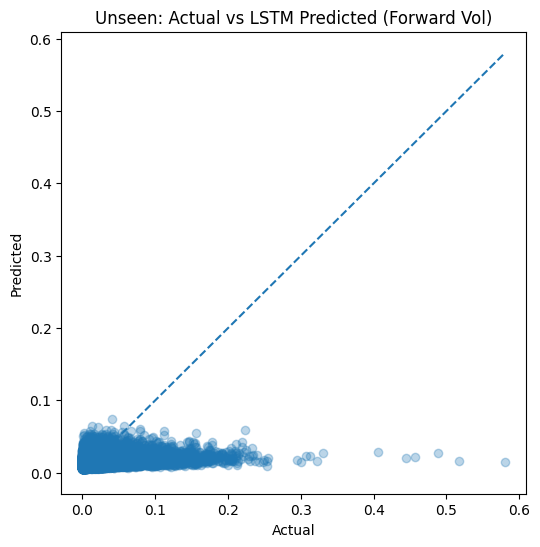

In [103]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(y_eval, y_pred_eval, alpha=0.3)

min_v = min(y_eval.min(), y_pred_eval.min())
max_v = max(y_eval.max(), y_pred_eval.max())
plt.plot([min_v, max_v], [min_v, max_v], linestyle="--")

plt.title("Unseen: Actual vs LSTM Predicted (Forward Vol)")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()


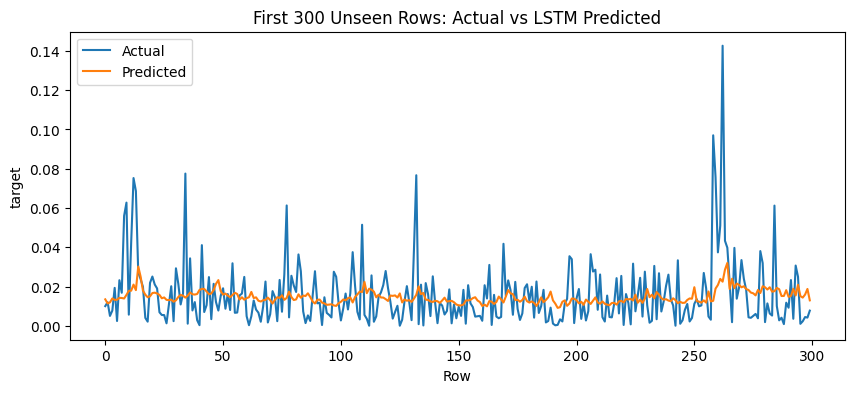

In [104]:
n_plot = min(300, len(y_eval))

plt.figure(figsize=(10, 4))
plt.plot(y_eval[:n_plot], label="Actual")
plt.plot(y_pred_eval[:n_plot], label="Predicted")
plt.title("First 300 Unseen Rows: Actual vs LSTM Predicted")
plt.xlabel("Row")
plt.ylabel(target_col)
plt.legend()
plt.show()


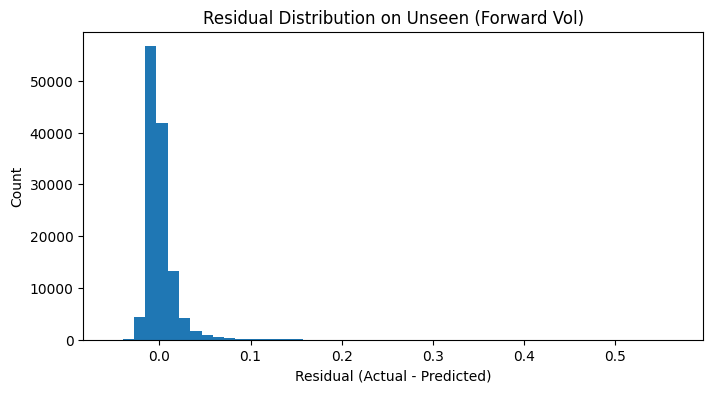

In [105]:
unseen_residuals = y_eval - y_pred_eval

plt.figure(figsize=(8, 4))
plt.hist(unseen_residuals, bins=50)
plt.title("Residual Distribution on Unseen (Forward Vol)")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Count")
plt.show()


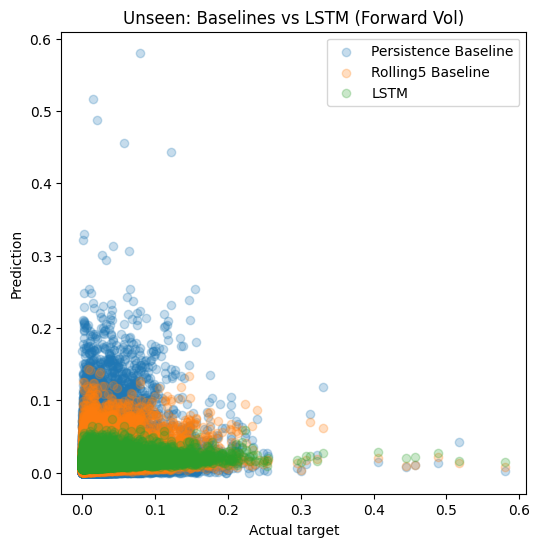

In [106]:
plt.figure(figsize=(6, 6))
plt.scatter(y_eval, baseline_persistence_unseen, alpha=0.25, label="Persistence Baseline")
plt.scatter(y_eval, baseline_rolling5_unseen, alpha=0.25, label="Rolling5 Baseline")
plt.scatter(y_eval, y_pred_eval, alpha=0.25, label="LSTM")
plt.title("Unseen: Baselines vs LSTM (Forward Vol)")
plt.xlabel(f"Actual {target_col}")
plt.ylabel("Prediction")
plt.legend()
plt.show()


In [107]:
# per stock

eval_df = meta_eval.copy()
eval_df["actual"] = y_eval
eval_df["predicted"] = y_pred_eval
eval_df["baseline_persistence_pred"] = baseline_persistence_unseen
eval_df["baseline_rolling5_pred"] = baseline_rolling5_unseen
eval_df["residual"] = eval_df["actual"] - eval_df["predicted"]

eval_df.head()


,Symbol,Date,actual,predicted,baseline_persistence_pred,baseline_rolling5_pred,residual
0,A,2025-03-21,0.010053,0.013509,0.003900,0.008559,-0.003456
1,A,2025-03-24,0.012042,0.011407,0.010053,0.008419,0.000635
2,A,2025-03-25,0.005075,0.011973,0.012042,0.009834,-0.006899
3,A,2025-03-26,0.007787,0.013974,0.005075,0.009398,-0.006187
4,A,2025-03-27,0.019351,0.013207,0.007787,0.007771,0.006144


In [108]:
def stock_metrics(group):
    y_true = group["actual"].values
    y_pred = group["predicted"].values
    y_base = group["baseline_persistence_pred"].values

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    base_rmse = np.sqrt(mean_squared_error(y_true, y_base))
    base_mae = mean_absolute_error(y_true, y_base)

    if len(y_true) > 1 and np.std(y_true) > 0 and np.std(y_pred) > 0:
        corr = np.corrcoef(y_true, y_pred)[0, 1]
    else:
        corr = np.nan

    if len(y_true) > 1 and np.std(y_true) > 0:
        r2 = r2_score(y_true, y_pred)
    else:
        r2 = np.nan

    return pd.Series({
        "n_obs": len(group),
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "corr": corr,
        "persistence_rmse": base_rmse,
        "persistence_mae": base_mae,
        "rmse_improvement_vs_persistence": base_rmse - rmse,
        "mae_improvement_vs_persistence": base_mae - mae
    })

per_stock_results = eval_df.groupby("Symbol").apply(stock_metrics).reset_index()
per_stock_results.head()


/var/folders/sx/rlv33lyd2zs6vjp3khdjp3dc0000gn/T/ipykernel_49420/1004184517.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_stock_results = eval_df.groupby("Symbol").apply(stock_metrics).reset_index()


,Symbol,n_obs,rmse,mae,r2,corr,persistence_rmse,persistence_mae,rmse_improvement_vs_persistence,mae_improvement_vs_persistence
0,A,250.0,0.013588,0.009974,0.015147,0.137529,0.017955,0.012974,0.004367,0.003000
1,AAPL,250.0,0.014757,0.009739,0.097906,0.336982,0.017649,0.010928,0.002893,0.001189
2,ABBV,250.0,0.012195,0.008866,-0.002975,0.106370,0.015957,0.011161,0.003762,0.002294
3,ABNB,250.0,0.015396,0.010503,0.040379,0.204140,0.020278,0.013194,0.004882,0.002691
4,ABT,250.0,0.011205,0.007002,0.014505,0.137664,0.016093,0.009686,0.004888,0.002684


In [109]:
per_stock_results[["rmse", "mae", "r2", "corr"]].describe()

,rmse,mae,r2,corr
count,499.000000,499.000000,499.000000,499.000000
mean,0.015365,0.009986,0.010811,0.146443
std,0.005947,0.003218,0.030387,0.068318
min,0.006251,0.005088,-0.094721,-0.055048
25%,0.011199,0.007745,-0.006657,0.100954
50%,0.013986,0.009147,0.011382,0.145575
75%,0.018130,0.011561,0.028840,0.190556
max,0.042322,0.022806,0.110640,0.359120


In [110]:
print("Stocks beating persistence baseline on RMSE:",
      (per_stock_results["rmse_improvement_vs_persistence"] > 0).sum())

print("Stocks beating persistence baseline on MAE:",
      (per_stock_results["mae_improvement_vs_persistence"] > 0).sum())

print("Median per-stock correlation:",
      per_stock_results["corr"].median())

print("Median per-stock R^2:",
      per_stock_results["r2"].median())


Stocks beating persistence baseline on RMSE: 499
Stocks beating persistence baseline on MAE: 497
Median per-stock correlation: 0.1455752170438303
Median per-stock R^2: 0.01138240098953247


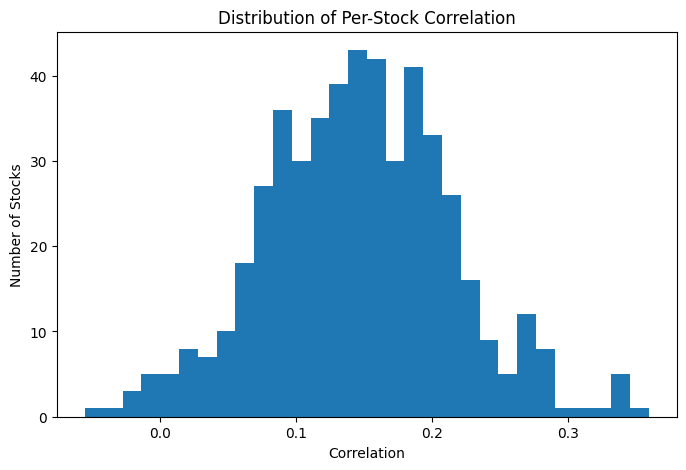

In [111]:
plt.figure(figsize=(8, 5))
plt.hist(per_stock_results["corr"].dropna(), bins=30)
plt.title("Distribution of Per-Stock Correlation")
plt.xlabel("Correlation")
plt.ylabel("Number of Stocks")
plt.show()

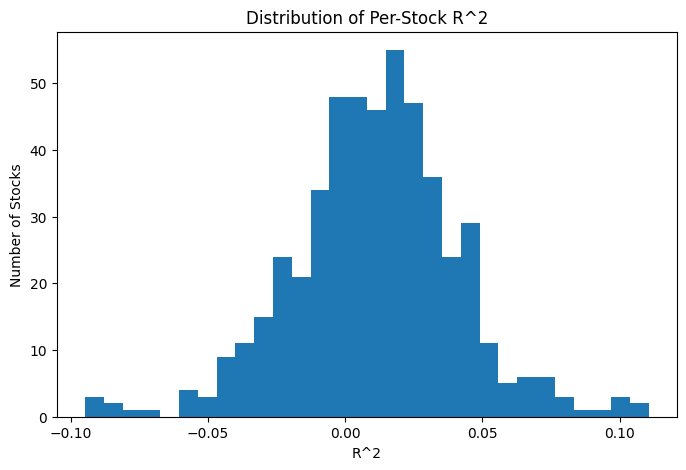

In [112]:
plt.figure(figsize=(8, 5))
plt.hist(per_stock_results["r2"].dropna(), bins=30)
plt.title("Distribution of Per-Stock R^2")
plt.xlabel("R^2")
plt.ylabel("Number of Stocks")
plt.show()

In [113]:
best_stocks = per_stock_results.sort_values("corr", ascending=False).head(10)
worst_stocks = per_stock_results.sort_values("corr", ascending=True).head(10)

print("Best stocks by correlation")
display(best_stocks)

print("Worst stocks by correlation")
display(worst_stocks)

Best stocks by correlation


,Symbol,n_obs,rmse,mae,r2,corr,persistence_rmse,persistence_mae,rmse_improvement_vs_persistence,mae_improvement_vs_persistence
225,HOLX,250.0,0.012332,0.007825,0.098521,0.359120,0.015877,0.007268,0.003546,-0.000558
365,PH,250.0,0.014128,0.008765,0.110640,0.338190,0.017483,0.011314,0.003355,0.002550
245,INTU,250.0,0.015468,0.010213,0.103989,0.337711,0.020788,0.013918,0.005321,0.003705
1,AAPL,250.0,0.014757,0.009739,0.097906,0.336982,0.017649,0.010928,0.002893,0.001189
124,CVNA,250.0,0.030428,0.019708,0.085868,0.336121,0.040567,0.026900,0.010138,0.007192
19,AKAM,250.0,0.019285,0.011654,0.079567,0.336086,0.024700,0.014877,0.005415,0.003224
278,LHX,250.0,0.010118,0.007520,0.103592,0.323926,0.013672,0.009799,0.003554,0.002280
31,AMZN,250.0,0.014982,0.010198,0.091830,0.308772,0.020093,0.013884,0.005110,0.003686
407,SNA,250.0,0.010557,0.007055,0.081237,0.294716,0.014482,0.009505,0.003925,0.002450
207,GLW,250.0,0.020617,0.013043,0.053676,0.289279,0.025897,0.016498,0.005280,0.003455


Worst stocks by correlation


,Symbol,n_obs,rmse,mae,r2,corr,persistence_rmse,persistence_mae,rmse_improvement_vs_persistence,mae_improvement_vs_persistence
176,EXE,250.0,0.015017,0.010866,-0.046464,-0.055048,0.020477,0.014353,0.005461,0.003487
64,BLDR,250.0,0.020412,0.015047,-0.082660,-0.041036,0.027241,0.020450,0.006829,0.005403
20,ALB,250.0,0.028775,0.020999,-0.094721,-0.022284,0.035888,0.026381,0.007112,0.005382
185,FDX,250.0,0.014951,0.009626,-0.050687,-0.020180,0.018947,0.012429,0.003995,0.002803
56,BDX,250.0,0.016431,0.008502,-0.023453,-0.017000,0.022461,0.011183,0.006030,0.002682
375,POOL,250.0,0.015820,0.010430,-0.031824,-0.012378,0.022386,0.014596,0.006566,0.004166
364,PGR,250.0,0.011325,0.007673,-0.036915,-0.007858,0.015161,0.009936,0.003836,0.002263
310,MOH,250.0,0.032418,0.016486,-0.034888,-0.007523,0.044127,0.022838,0.011709,0.006352
160,ELV,250.0,0.020166,0.012261,-0.033801,-0.002536,0.024550,0.014586,0.004383,0.002326
97,CME,250.0,0.008178,0.006155,-0.042895,-0.001551,0.010822,0.008075,0.002644,0.001920


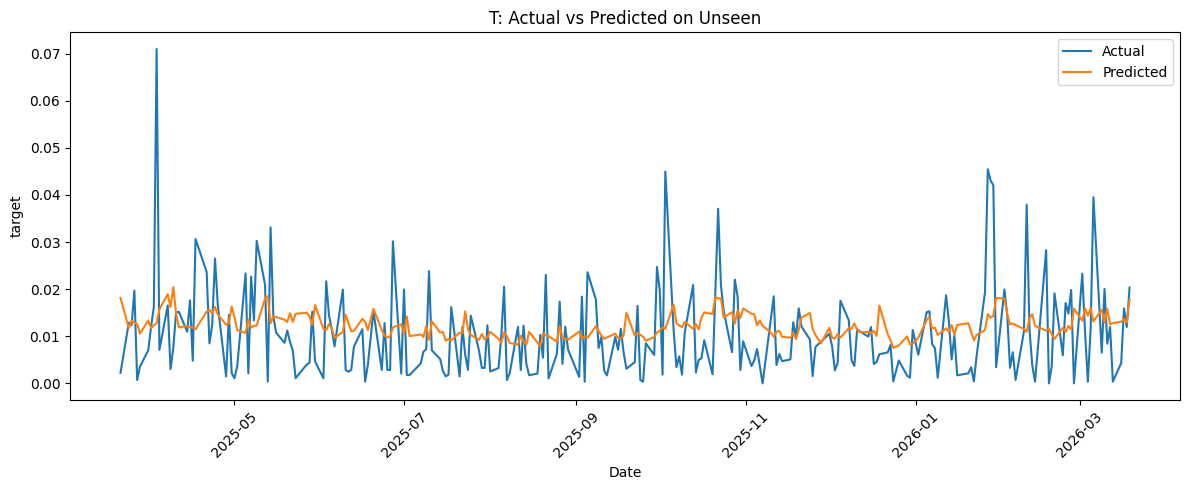

In [114]:
symbol_to_plot = "T"

stock_df = eval_df[eval_df["Symbol"] == symbol_to_plot].sort_values("Date")

plt.figure(figsize=(12, 5))
plt.plot(stock_df["Date"], stock_df["actual"], label="Actual")
plt.plot(stock_df["Date"], stock_df["predicted"], label="Predicted")
plt.title(f"{symbol_to_plot}: Actual vs Predicted on Unseen")
plt.xlabel("Date")
plt.ylabel(target_col)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


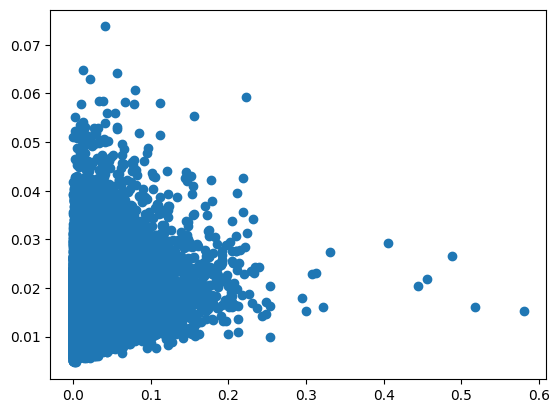

In [115]:
plt.scatter(y_unseen, y_unseen_pred)

In [116]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

base_rmse = np.sqrt(mean_squared_error(y_eval, y_pred_eval))
base_mae = mean_absolute_error(y_eval, y_pred_eval)
base_r2 = r2_score(y_eval, y_pred_eval)

print("Base unseen RMSE (LSTM, aligned eval):", base_rmse)
print("Base unseen MAE (LSTM, aligned eval):", base_mae)
print("Base unseen R^2 (LSTM, aligned eval):", base_r2)


Base unseen RMSE (LSTM, aligned eval): 0.01647273737611756
Base unseen MAE (LSTM, aligned eval): 0.00998605601489544
Base unseen R^2 (LSTM, aligned eval): 0.08671468496322632


In [117]:
def permutation_importance_lstm(model, X_scaled, y_true, feature_cols, y_mean, y_std, n_repeats=5, random_state=42):
    rng = np.random.default_rng(random_state)
    results = []

    # baseline predictions
    y_pred_scaled = model.predict(X_scaled, verbose=0).flatten()
    y_pred = y_pred_scaled * y_std + y_mean

    baseline_rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    baseline_mae = mean_absolute_error(y_true, y_pred)
    baseline_r2 = r2_score(y_true, y_pred)

    n_samples, lookback, n_features = X_scaled.shape

    for j, feature in enumerate(feature_cols):
        rmse_scores = []
        mae_scores = []
        r2_scores = []

        for _ in range(n_repeats):
            X_perm = X_scaled.copy()

            # shuffle this feature across samples, keeping time order inside each sample
            shuffled_idx = rng.permutation(n_samples)
            X_perm[:, :, j] = X_perm[shuffled_idx, :, j]

            y_perm_scaled = model.predict(X_perm, verbose=0).flatten()
            y_perm = y_perm_scaled * y_std + y_mean

            rmse_scores.append(np.sqrt(mean_squared_error(y_true, y_perm)))
            mae_scores.append(mean_absolute_error(y_true, y_perm))
            r2_scores.append(r2_score(y_true, y_perm))

        results.append({
            "feature": feature,
            "baseline_rmse": baseline_rmse,
            "perm_rmse_mean": np.mean(rmse_scores),
            "rmse_increase": np.mean(rmse_scores) - baseline_rmse,
            "baseline_mae": baseline_mae,
            "perm_mae_mean": np.mean(mae_scores),
            "mae_increase": np.mean(mae_scores) - baseline_mae,
            "baseline_r2": baseline_r2,
            "perm_r2_mean": np.mean(r2_scores),
            "r2_drop": baseline_r2 - np.mean(r2_scores),
        })

    return pd.DataFrame(results).sort_values("rmse_increase", ascending=False).reset_index(drop=True)

In [118]:
perm_importance_df = permutation_importance_lstm(
    model=model,
    X_scaled=X_unseen_scaled,
    y_true=y_unseen,
    feature_cols=feature_cols,
    y_mean=y_mean,
    y_std=y_std,
    n_repeats=5,
    random_state=42
)

perm_importance_df

,feature,baseline_rmse,perm_rmse_mean,rmse_increase,baseline_mae,perm_mae_mean,mae_increase,baseline_r2,perm_r2_mean,r2_drop
0,close_lag_5d,0.016473,0.016864,0.000391,0.009986,0.010377,0.000391,0.086715,0.042842,0.043873
1,close_lag_1d,0.016473,0.016827,0.000355,0.009986,0.010383,0.000397,0.086715,0.046956,0.039758
2,volume_pct_change_1d,0.016473,0.016782,0.000309,0.009986,0.010386,0.000400,0.086715,0.052110,0.034605
3,daily_volatility_lag_21d,0.016473,0.016681,0.000209,0.009986,0.010158,0.000172,0.086715,0.063421,0.023293
4,volume_lag_1d,0.016473,0.016662,0.000189,0.009986,0.010200,0.000213,0.086715,0.065593,0.021122
5,daily_volatility_lag_1d,0.016473,0.016627,0.000154,0.009986,0.010372,0.000386,0.086715,0.069554,0.017161
6,daily_volatility_lag_5d,0.016473,0.016621,0.000148,0.009986,0.010119,0.000133,0.086715,0.070245,0.016470
7,daily_volatility_lag_2d,0.016473,0.016590,0.000117,0.009986,0.010244,0.000258,0.086715,0.073689,0.013025
8,volume_lag_5d,0.016473,0.016574,0.000102,0.009986,0.010129,0.000143,0.086715,0.075422,0.011293


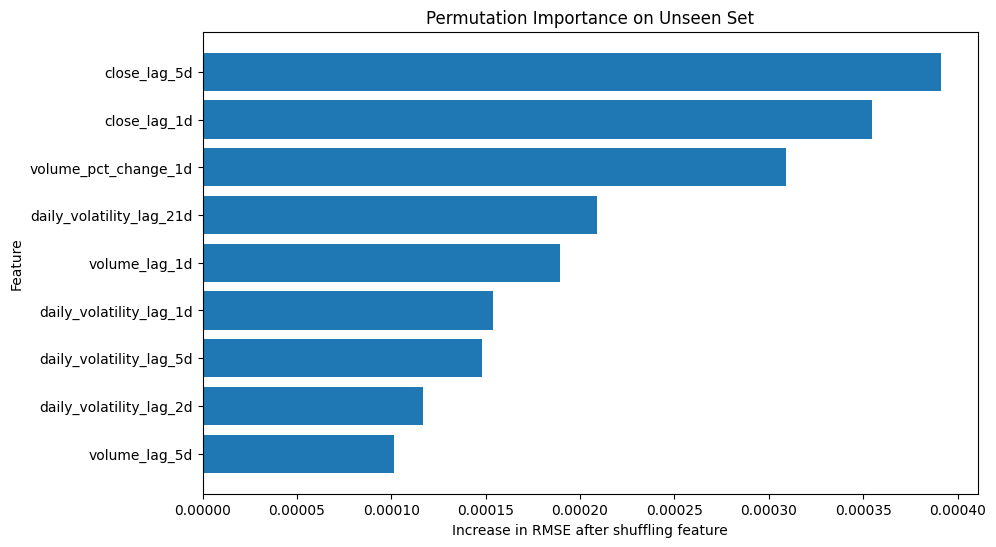

In [119]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(perm_importance_df["feature"], perm_importance_df["rmse_increase"])
plt.gca().invert_yaxis()
plt.title("Permutation Importance on Unseen Set")
plt.xlabel("Increase in RMSE after shuffling feature")
plt.ylabel("Feature")
plt.show()

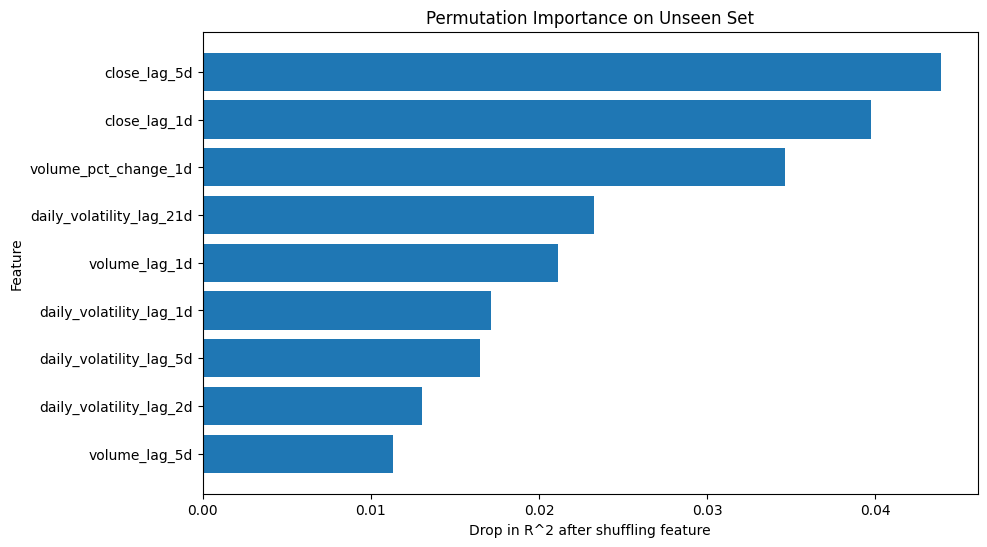

In [120]:
plt.figure(figsize=(10, 6))
plt.barh(perm_importance_df["feature"], perm_importance_df["r2_drop"])
plt.gca().invert_yaxis()
plt.title("Permutation Importance on Unseen Set")
plt.xlabel("Drop in R^2 after shuffling feature")
plt.ylabel("Feature")
plt.show()